In [1]:
# --- SETUP: DATA LOADING ---
# This cell checks if you are running on Google Colab.
# If yes, it clones the course repository so you have the data files.

import sys
import os

if 'google.colab' in sys.modules:
    # 1. Clone the repository (if not already there)
    repo_name = 'SIO175_DataAnalysis'
    if not os.path.exists(repo_name):
        !git clone https://github.com/isidora-rojas/SIO175_DataAnalysis.git

    # 2. Navigate to the Module 1 folder where the notebook and data reside
    # Note: We must change directory to the specific module folder!
    target_dir = os.path.join(repo_name, 'Module_1')
    if os.path.exists(target_dir):
        os.chdir(target_dir)
        print(f"Working directory changed to: {os.getcwd()}")
    else:
        print("Error: Module directory not found.")

print("Setup Complete! Data files are now available.")

Setup Complete! Data files are now available.


# Demo 1

## Python plotting, logical expressions, and histograms using SIO pier temperature time series data

functions used in this notebook:

*scipy*:
- loadmat

*Pandas*
- .DataFrame () : creates dataframe from .csv-like file
- .to_datetime() : converts to datetime formatting
- .iloc () : integer-based indexing
- .dayofyear : converts date into an integer representing position in the calendar year

*NumPy*
- .arange(): list of numbers

*matplotlib*
- pyplot.plot() : plotting by defining x and y variables
- mdates.DateFormater(): adjusts datetime formatting 

In [64]:
# libraries i used for this assignment
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [5]:
data = loadmat('data/SIO_TEMP_1917_2025_py.mat', squeeze_me=True)
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Jan  5 16:40:56 2026',
 '__version__': '1.0',
 '__globals__': [],
 'T': array([11.5, 11.5, 11.9, ..., 18.7, 18.5, 19.1]),
 'dy': array([ 1,  2,  3, ..., 29, 30, 31], dtype=uint8),
 'mo': array([ 1,  1,  1, ..., 10, 10, 10], dtype=uint8),
 'None': MatlabOpaque([(b'time_str', b'MCOS', b'string', array([3707764736,          2,          1,          1,          1,
                               1], dtype=uint32))                                                                  ],
              dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]),
 'yr': array([1917, 1917, 1917, ..., 2025, 2025, 2025], dtype=uint16),
 '__function_workspace__': array([[ 0,  1, 73, ...,  0,  0,  0]], dtype=uint8)}

not very readable. We will use the library Pandas to organize the data into a dataframe for easier handling

In [12]:
# create dataframe
df = pd.DataFrame({
    'year': data['yr'],
    'month': data['mo'],
    'day': data['dy'],
    'T': data['T'],
})
df

,year,month,day,T
0,1917,1,1,11.5
1,1917,1,2,11.5
2,1917,1,3,11.9
3,1917,1,4,11.5
4,1917,1,5,11.7
...,...,...,...,...
39746,2025,10,27,18.5
39747,2025,10,28,18.2
39748,2025,10,29,18.7
39749,2025,10,30,18.5


In [13]:
# I want to make the index the date for easy querying later 
df.index = pd.to_datetime(df[['year', 'month', 'day']])
df

,year,month,day,T
1917-01-01,1917,1,1,11.5
1917-01-02,1917,1,2,11.5
1917-01-03,1917,1,3,11.9
1917-01-04,1917,1,4,11.5
1917-01-05,1917,1,5,11.7
...,...,...,...,...
2025-10-27,2025,10,27,18.5
2025-10-28,2025,10,28,18.2
2025-10-29,2025,10,29,18.7
2025-10-30,2025,10,30,18.5


#### Display first, second, and last time values

In [23]:
print(df[0:2])

            year  month  day     T
1917-01-01  1917      1    1  11.5
1917-01-02  1917      1    2  11.5


In [22]:
print(df[-1:])

            year  month  day     T
2025-10-31  2025     10   31  19.1


In [30]:
string = 'The dataset ranges from {} to {}.'.format(df.index[0].date(), df.index[-1].date())
print(string)

The dataset ranges from 1917-01-01 to 2025-10-31.


#### Display first 10 temperature values

In [32]:
df['T'][:10]

1917-01-01    11.500000
1917-01-02    11.500000
1917-01-03    11.900000
1917-01-04    11.500000
1917-01-05    11.700000
1917-01-06    11.900000
1917-01-07    12.033333
1917-01-08    12.166667
1917-01-09    12.300000
1917-01-10    12.200000
Name: T, dtype: float64

#### Displey every other value of first 10 values

In [34]:
print(df['T'][:10:2])

1917-01-01    11.500000
1917-01-03    11.900000
1917-01-05    11.700000
1917-01-07    12.033333
1917-01-09    12.300000
Name: T, dtype: float64


In [35]:
print(df['T'].iloc[:10:2])

1917-01-01    11.500000
1917-01-03    11.900000
1917-01-05    11.700000
1917-01-07    12.033333
1917-01-09    12.300000
Name: T, dtype: float64


#### plot a time series of surface temperature

Text(0.5, 1.0, 'SIO Pier SST 1917-2025')

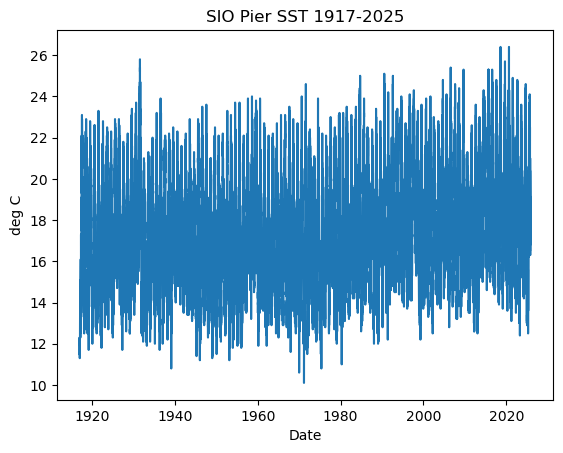

In [37]:
plt.plot(df.index, df['T'])
plt.xlabel('Date')
plt.ylabel('deg C')
plt.title("SIO Pier SST 1917-2025")

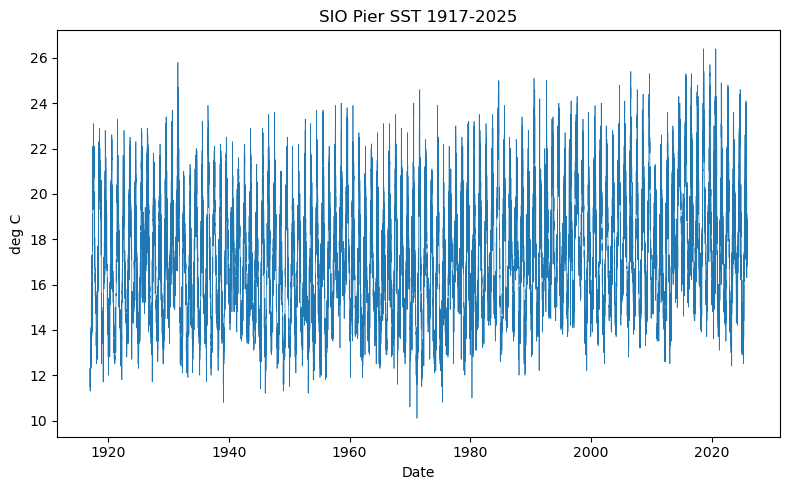

In [40]:
fig, ax = plt.subplots(figsize=(8,5))

plt.plot(df.index, df['T'], linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('deg C')
plt.title("SIO Pier SST 1917-2025")

plt.tight_layout()


#### Logical Expression in Python (Pandas/Numpy)

Python represents data using the `bool` date time which uses `True` and `False`.

In Pandas DataFrames, logical arrays are called **Boolean Masks**. These are returned by:
- **Relational Operators**: `==`, `!=`, `<`, `>`
- **Logical Operators**: `&` (and), `|` (or), `~` (not)
- **Pandas Functions**: `.isna()`, `.isnull()`, `.any()`, `.all()`, `.isin()`

In [43]:
x = np.arange(10)
print(x)

[0 1 2 3 4 5 6 7 8 9]


In [48]:
x > 5

array([False, False, False, False, False, False,  True,  True,  True,
        True])

In [49]:
x[x>5]

array([6, 7, 8, 9])

In [50]:
x == 3

array([False, False, False,  True, False, False, False, False, False,
       False])

In [51]:
x[x==3]

array([3])

In [53]:
(x > 5) & (x < 8)

array([False, False, False, False, False, False,  True,  True, False,
       False])

In [54]:
x[(x > 5) & (x < 8)]

array([6, 7])

In [57]:
(x==4) | (x > 8)

array([False, False, False, False,  True, False, False, False, False,
        True])

In [58]:
x[(x==4) | (x > 8)]

array([4, 9])

This can similarly be applied to dataframes, going back to our temperature dataframe:

In [59]:
df[df['T'] > 20]

,year,month,day,T
1917-06-24,1917,6,24,20.3
1917-06-25,1917,6,25,20.9
1917-06-28,1917,6,28,20.3
1917-06-29,1917,6,29,20.9
1917-06-30,1917,6,30,20.9
...,...,...,...,...
2025-09-19,2025,9,19,21.9
2025-09-27,2025,9,27,20.4
2025-09-29,2025,9,29,20.1
2025-10-02,2025,10,2,21.0


#### Plot surface temperature for 2018

Text(0.5, 1.0, 'SIO Pier SST (2018)')

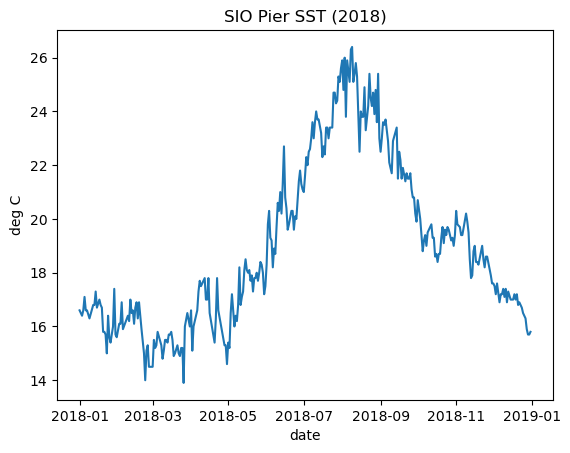

In [62]:
# query data in 2018
df_2018 = df[df['year'] == 2018]
# plot
fig, ax = plt.subplots()

ax.plot(df_2018.index, df_2018['T'])

ax.set_xlabel('date')
ax.set_ylabel('deg C')
ax.set_title('SIO Pier SST (2018)')

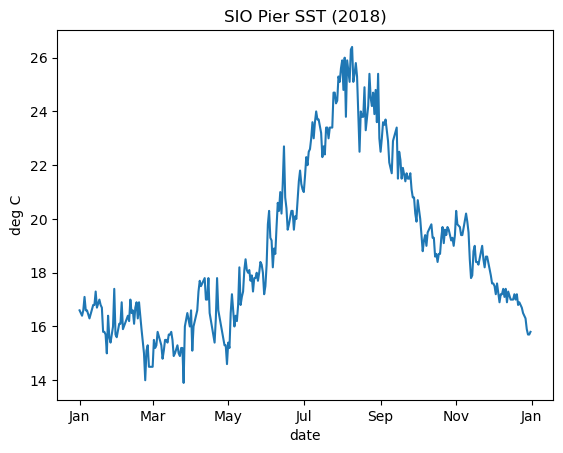

In [65]:
# query data in 2018
df_2018 = df[df['year'] == 2018]
# plot
fig, ax = plt.subplots()

ax.plot(df_2018.index, df_2018['T'])

ax.set_xlabel('date')
ax.set_ylabel('deg C')
ax.set_title('SIO Pier SST (2018)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

#### plotting year 2018 using set_xlim

Text(0.5, 1.0, 'SIO Pier SST (2018)')

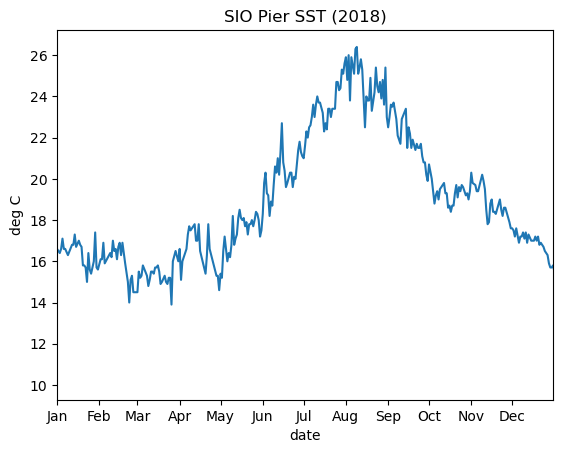

In [72]:
fig, ax = plt.subplots()

ax.plot(df.index, df['T'])

left = pd.to_datetime('2018-01-01')
right = pd.to_datetime('2018-12-31')

ax.set_xlim(left, right)

ax.set_xlabel('date')
ax.set_ylabel('deg C')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_title('SIO Pier SST (2018)')

#### Plot August 2018

#### Plot July-September 2018

#### Plot temperature from 2010 - 2022

#### Plot two time series on the same plot - 2010 and 2018

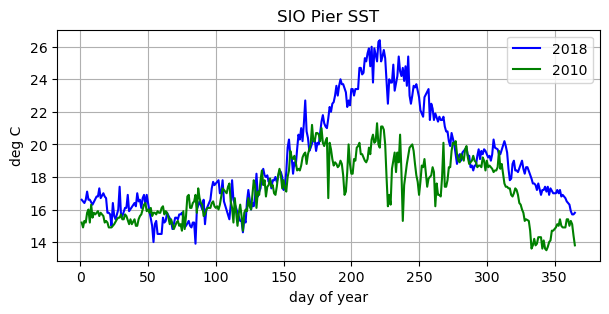

In [86]:
df_2018 = df[df['year'] == 2018]
df_2010 = df[df['year'] == 2010]

fig, ax = plt.subplots(figsize=(7,3))

ax.plot(df_2018.index.dayofyear, df_2018['T'], color='blue', label = '2018')
ax.plot(df_2010.index.dayofyear, df_2010['T'], color = 'green', label = '2010')

ax.set_xlabel('day of year')
ax.set_ylabel('deg C')
ax.set_title('SIO Pier SST')
ax.grid(True)
ax.legend()

#### Indicate max and min values using symbols

In [ ]:
df['T'].max() # find max values
df['T'].idxmax() # find index location of max values

Timestamp('2018-08-09 00:00:00')

In [ ]:
df['T'].min()
df['T'].idxmin() 

Timestamp('1971-03-02 00:00:00')

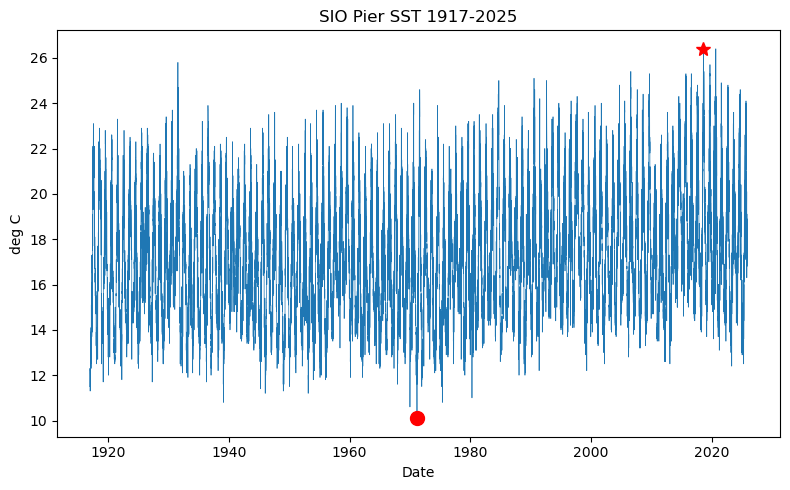

In [96]:
#plot data from before
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(df.index, df['T'], linewidth=0.5)

ax.plot(df['T'].idxmax(), df['T'].max(), 'r*', markersize=10)
ax.plot(df['T'].idxmin(), df['T'].min(), 'ro', markersize=10)

plt.xlabel('Date')
plt.ylabel('deg C')
plt.title("SIO Pier SST 1917-2025")

plt.tight_layout()
